Install Required Libraries

In [5]:
!pip install pandas numpy scikit-learn joblib matplotlib seaborn 

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib


Load Dataset

In [2]:
df = pd.read_csv("loan_dataset_20000.csv")


In [3]:
df.columns

Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='str')

Select ONLY Required Inputs & Output

In [4]:
input_features = [
    "age",
    "gender",
    "marital_status",
    "education_level",
    "annual_income",
    "employment_status",
    "debt_to_income_ratio",
    "credit_score",
    "loan_amount",
    "loan_purpose",
    "loan_term",
    "num_of_open_accounts",
    "total_credit_limit",
    "delinquency_history"
]

target = "loan_paid_back"

df = df[input_features + [target]]


Display Dataset After Column Selection

In [5]:
df.head()

,age,gender,marital_status,education_level,annual_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,loan_term,num_of_open_accounts,total_credit_limit,delinquency_history,loan_paid_back
0,59,Male,Married,Master's,24240.19,Employed,0.074,743,17173.72,Car,36,7,40833.47,1,1
1,72,Female,Married,Bachelor's,20172.98,Employed,0.219,531,22663.89,Debt consolidation,60,5,27968.01,1,1
2,49,Female,Single,High School,26181.80,Employed,0.234,779,3631.36,Business,60,2,15502.25,0,1
3,35,Female,Single,High School,11873.84,Employed,0.264,809,14939.23,Other,36,7,18157.79,4,1
4,63,Other,Single,Other,25326.44,Employed,0.260,663,16551.71,Car,60,1,17467.56,2,1


Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  str    
 2   marital_status        20000 non-null  str    
 3   education_level       20000 non-null  str    
 4   annual_income         20000 non-null  float64
 5   employment_status     20000 non-null  str    
 6   debt_to_income_ratio  20000 non-null  float64
 7   credit_score          20000 non-null  int64  
 8   loan_amount           20000 non-null  float64
 9   loan_purpose          20000 non-null  str    
 10  loan_term             20000 non-null  int64  
 11  num_of_open_accounts  20000 non-null  int64  
 12  total_credit_limit    20000 non-null  float64
 13  delinquency_history   20000 non-null  int64  
 14  loan_paid_back        20000 non-null  int64  
dtypes: float64(4), int64(6), str(5

Check Missing Values

In [7]:
df.isnull().sum()

age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
loan_term               0
num_of_open_accounts    0
total_credit_limit      0
delinquency_history     0
loan_paid_back          0
dtype: int64

Remove Missing Values

In [8]:
df.dropna(inplace=True)

Check Duplicate Rows

In [9]:
df.duplicated().sum()

np.int64(0)

Remove Duplicate Rows

In [10]:
df.drop_duplicates(inplace=True)

Check Noise / Outliers (Example)

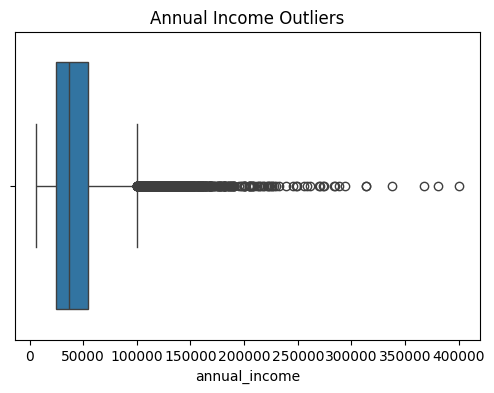

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["annual_income"])
plt.title("Annual Income Outliers")
plt.show()

Encode Categorical Columns

In [12]:
categorical_columns = [
    "gender",
    "marital_status",
    "education_level",
    "employment_status",
    "loan_purpose"
]

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


Separate Inputs (X) and Output (y)

In [13]:
X = df[input_features]
y = df[target]

Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Logistic Regression Model

In [16]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Make Predictions

In [17]:
y_pred = model.predict(X_test)

Display Accuracy

In [18]:
accuracy_score(y_test, y_pred)

0.884

Confusion Matrix

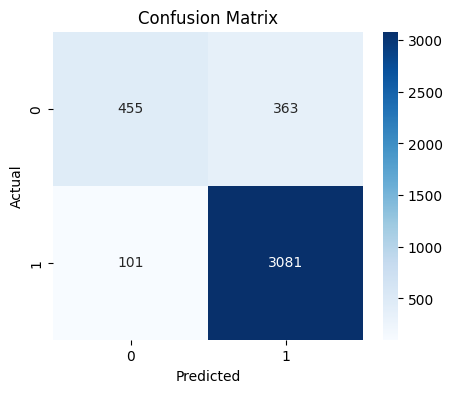

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()